# Inverse PINN for simultaneous identification of displacement and a spatially varying Young's modulus

The goal is to identify both the displacement $u(x)$ and an unknown nonconstant Young's modulus $E(x)$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),
\qquad
0<a<\frac{1}{2\pi}.
$$

The hidden spatially varying Young's modulus is fixed as

$$
E_{\mathrm{true}}(x)=1+0.5x.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),
\qquad
\sigma(x)=E(x)u'(x),
$$

and equilibrium requires

$$
\frac{\mathrm d}{\mathrm dx}
\left(E(x)u'(x)\right)+b(x)=0.
$$

The corresponding known body force is

$$
b_{\mathrm{known}}(x)
=4\pi^2a(1+0.5x)\sin(2\pi x)
-\pi a\cos(2\pi x).
$$

The PINN learns $u_\theta(x)$ and $E_\theta(x)$ as two outputs of one shared network from the equilibrium equation and sparse displacement observations.

## 1. Library imports

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.set_default_dtype(torch.float64)

## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}
=u_{\mathrm{exact}}(x_i)+\eta_i,
\qquad
\eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$



In [108]:
USE_NOISY_DATA = False
NOISE_RELATIVE_STD = 0.02
L = 1.0
INITIAL_E = 0.8
AMPLITUDE = 0.05
N_PDE_TRAIN = 1000
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_REGULARIZATION = 200
N_DATA_TOTAL = 26
TRAIN_FRACTION = 0.8
N_DATA_TRAIN = int(TRAIN_FRACTION * N_DATA_TOTAL)
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN
EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 0.003
SEED = 42
WEIGHT_PDE = 1.0
WEIGHT_DATA = 100.0
WEIGHT_REGULARIZATION = 1e-9
NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE
torch.manual_seed(SEED)

## 3. Exact fields for synthetic data and evaluation

In [109]:
def exact_solution(x):
    """Exact displacement used to generate synthetic observations."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)

def exact_strain(x):
    """Exact strain u'(x)."""
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)

def exact_young_modulus(x):
    """Hidden spatially varying Young modulus used for the benchmark."""
    return 1.0 + 0.5 * x * torch.cos(torch.pi * x)

def exact_stress(x):
    """Exact stress E(x)u'(x)."""
    return exact_young_modulus(x) * exact_strain(x)

def known_body_force(x):
    young_modulus = exact_young_modulus(x)
    dE_dx = (
        0.5 * torch.cos(torch.pi * x)
        - 0.5 * torch.pi * x * torch.sin(torch.pi * x)
    )

    return (
        4.0 * torch.pi**2 * AMPLITUDE
        * young_modulus * torch.sin(2.0 * torch.pi * x)
        - 2.0 * torch.pi * AMPLITUDE
        * dE_dx * torch.cos(2.0 * torch.pi * x)
    )

## 4. One neural network for displacement and Young's modulus

One shared neural network with two outputs approximates

$$
u(x)\approx u_\theta(x),
\qquad
E(x)\approx E_\theta(x).
$$

The output vector is $[u_\theta(x),E_\theta(x)]^{\mathsf T}$. The second output is initialized close to `INITIAL_E`, but it remains an unconstrained trainable function.

In [110]:
class InverseVariableModulusPINN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(), 
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(), 
            nn.Linear(30, 2)
            )
        
        with torch.no_grad():
            self.net[-1].bias[0] = 0.0
            self.net[-1].bias[1] = INITIAL_E

    def forward(self, x):
        return self.net(x)

    def displacement(self, x):
        return self.forward(x)[:, 0:1]

    def young_modulus(self, x):
        return self.forward(x)[:, 1:2]
model = InverseVariableModulusPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)

## 5. Collocation points and PDE batching

Training collocation points are sampled uniformly from $(0,1)$ and divided into shuffled PDE mini-batches. The independent test points are not used during training.

In [111]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)
pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)
pde_test_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)
REGULARIZATION_DX = L / N_REGULARIZATION
x_regularization = (torch.arange(N_REGULARIZATION).view(-1, 1) + 0.5) * REGULARIZATION_DX

## 6. Train/test split of sparse displacement observations

Sparse sensor locations cover the complete bar and are randomly split into training and held-out test subsets. Only displacement is observed; no values of the Young modulus are supplied to the loss.

In [112]:
x_data_all = torch.linspace(0.0, L, N_DATA_TOTAL).view(-1, 1)
split_generator = torch.Generator().manual_seed(SEED + 5)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_indices = permutation[:N_DATA_TRAIN]
test_indices = permutation[N_DATA_TRAIN:]
u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()
if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 6)
    measurement_noise = NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)
    u_data_all_observed += measurement_noise
x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]
x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]
print(f'Sparse data split: {N_DATA_TRAIN} train, {N_DATA_TEST} test')

Sparse data split: 20 train, 6 test


## 7. PDE residual, modulus regularization, and inverse loss

For a spatially varying modulus, the equilibrium residual must contain the derivative of the complete stress:

$$
r_{\mathrm{PDE},\theta}(x)
=\frac{\mathrm d}{\mathrm dx}
\left(E_\theta(x)u_\theta'(x)\right)
+b_{\mathrm{known}}(x).
$$

In particular,

$$
\frac{\mathrm d}{\mathrm dx}(E_\theta u_\theta')
=E_\theta'u_\theta'+E_\theta u_\theta''.
$$

To suppress nonphysical oscillations of the reconstructed modulus while allowing a nonzero slope, we regularize its curvature. The integral is approximated by the midpoint rectangle rule:

$$
\mathcal L_{\mathrm{reg}}
=\int_0^1\left|E_\theta''(x)\right|^2\,\mathrm dx
\approx h\sum_{k=1}^{N_{\mathrm{reg}}}
\left|E_\theta''(x_{\mathrm{reg},k})\right|^2.
$$

The complete training loss is

$$
\mathcal L
=w_{\mathrm{PDE}}\mathcal L_{\mathrm{PDE}}
+w_{\mathrm{data}}\mathcal L_{\mathrm{data}}
+w_{\mathrm{reg}}\mathcal L_{\mathrm{reg}}.
$$

In [113]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    fields = model(x)
    u = fields[:, 0:1]
    young_modulus = fields[:, 1:2]
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    stress = young_modulus * du_dx
    dstress_dx = torch.autograd.grad(stress, x, grad_outputs=torch.ones_like(stress), create_graph=training)[0]
    return dstress_dx + known_body_force(x)

def young_modulus_curvature(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    young_modulus = model.young_modulus(x)
    dE_dx = torch.autograd.grad(young_modulus, x, grad_outputs=torch.ones_like(young_modulus), create_graph=True)[0]
    return torch.autograd.grad(dE_dx, x, grad_outputs=torch.ones_like(dE_dx), create_graph=training)[0]

def compute_losses(x_pde):
    residual = pde_residual(x_pde, training=True)
    loss_pde = torch.mean(residual ** 2)
    modulus_curvature = young_modulus_curvature(x_regularization, training=True)
    loss_regularization = REGULARIZATION_DX * torch.sum(modulus_curvature ** 2)
    u_data_prediction = model.displacement(x_data_train)
    loss_data = torch.mean((u_data_prediction - u_data_train) ** 2)
    loss = WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data + WEIGHT_REGULARIZATION * loss_regularization
    return (loss, loss_pde, loss_data, loss_regularization)

## 8. Training with Adam mini-batches and full-batch L-BFGS

In [114]:
loss_history = []
pde_loss_history = []
data_loss_history = []
regularization_loss_history = []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    for x_pde_batch, in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(x_pde_batch)
        loss = losses[0]
        loss.backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    epoch_losses = epoch_sums / len(pde_loader)
    loss_value, pde_value, data_value, reg_value = epoch_losses
    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    regularization_loss_history.append(reg_value)
    if epoch % 250 == 0:
        print(f'Adam | epoch {epoch:5d} | loss={loss_value:.6e} | PDE={pde_value:.6e} | data={data_value:.6e} | reg={reg_value:.6e}')
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, history_size=50, line_search_fn='strong_wolfe')
for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    losses = compute_losses(x_pde_train)
    loss, loss_pde, loss_data, loss_regularization = losses
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    regularization_loss_history.append(loss_regularization.detach().item())
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f'L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | data={loss_data.item():.6e} | reg={loss_regularization.item():.6e}')
model.eval()

Adam | epoch     0 | loss=9.440902e-01 | PDE=8.373433e-01 | data=1.067469e-03 | reg=9.815888e-01
Adam | epoch   250 | loss=3.021373e-04 | PDE=2.080504e-04 | data=9.408450e-07 | reg=2.452127e+00
Adam | epoch   500 | loss=2.034702e-04 | PDE=1.335210e-04 | data=6.994399e-07 | reg=5.164855e+00
Adam | epoch   750 | loss=5.729802e-04 | PDE=4.473178e-04 | data=1.256553e-06 | reg=7.056259e+00
Adam | epoch  1000 | loss=2.128035e-05 | PDE=1.509710e-05 | data=6.175748e-08 | reg=7.499550e+00
Adam | epoch  1250 | loss=2.049868e-05 | PDE=1.541133e-05 | data=5.079070e-08 | reg=8.284596e+00
Adam | epoch  1500 | loss=2.615879e-05 | PDE=1.733153e-05 | data=8.818388e-08 | reg=8.865127e+00
Adam | epoch  1750 | loss=8.059417e-05 | PDE=6.088592e-05 | data=1.969936e-07 | reg=8.894212e+00
L-BFGS | epoch  1900 | loss=5.123251e-06 | PDE=4.129756e-06 | data=9.848674e-09 | reg=8.627512e+00
L-BFGS | epoch  1950 | loss=4.971644e-06 | PDE=4.036504e-06 | data=9.264726e-09 | reg=8.667691e+00
L-BFGS | epoch  1999 | los

InverseVariableModulusPINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=2, bias=True)
  )
)

## 9. Evaluation on independent test points

In [115]:
with torch.no_grad():
    u_sparse_test_prediction = model.displacement(x_data_test)
    u_test_prediction = model.displacement(x_pde_test)
    E_test_prediction = model.young_modulus(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)
    E_test_exact = exact_young_modulus(x_pde_test)

    def r2_score(prediction, target):
        ss_res = torch.sum((prediction - target) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return (1.0 - ss_res / ss_tot).item()

    def relative_l2_error(prediction, target):
        numerator = torch.linalg.vector_norm(prediction - target)
        denominator = torch.linalg.vector_norm(target)
        return (numerator / denominator).item()
    r2_u_test = r2_score(u_test_prediction, u_test_exact)
    relative_l2_u_test = relative_l2_error(u_test_prediction, u_test_exact)
    r2_E_test = r2_score(E_test_prediction, E_test_exact)
    relative_l2_E_test = relative_l2_error(E_test_prediction, E_test_exact)
pde_test_residual = pde_residual(x_pde_test, training=False).detach()
metrics = {'R2_displacement_test': r2_u_test, 'relative_L2_displacement_test': relative_l2_u_test, 
           'R2_young_modulus_test': r2_E_test,
           'relative_L2_young_modulus_test': relative_l2_E_test}
print('=' * 72)
print('INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND VARIABLE MODULUS')
print('=' * 72)
print(f"Data mode:                         {('noisy' if USE_NOISY_DATA else 'exact')}")
print(f'Displacement R2:                   {r2_u_test:.8f}')
print(f'Relative L2 displacement error:   {relative_l2_u_test: .6e}')
print(f'Young-modulus R2:                  {r2_E_test:.8f}')
print(f'Relative L2 Young-modulus error:  {relative_l2_E_test: .6e}')
print('=' * 72)
metrics

INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND VARIABLE MODULUS
Data mode:                         exact
Displacement R2:                   0.99998066
Relative L2 displacement error:    4.396800e-03
Young-modulus R2:                  0.99610780
Relative L2 Young-modulus error:   1.339207e-02


{'R2_displacement_test': 0.9999806608670904,
 'relative_L2_displacement_test': 0.00439680031387223,
 'R2_young_modulus_test': 0.9961077989234224,
 'relative_L2_young_modulus_test': 0.013392068094517227}

## 10. Visualization functions

In [116]:
x_plot = torch.linspace(0.0, L, 400).view(-1, 1)

def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(x_pde_train.numpy(), np.ones((len(x_pde_train), 1)), s=16, alpha=0.5, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_test.numpy(), np.zeros((len(x_pde_test), 1)), s=16, marker='x', alpha=0.5, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1], labels=['test', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')
    u_plot_exact = exact_solution(x_plot)
    axes[1].plot(x_plot.numpy(), u_plot_exact.numpy(), 'k--', label='Exact displacement')
    axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(), color='tab:blue', s=45, label=f'Train measurements ({N_DATA_TRAIN})', zorder=3)
    axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=55, label=f'Test measurements ({N_DATA_TEST})', zorder=3)
    axes[1].set(xlabel='x', ylabel='u(x)', title='Gaussian-noisy sparse data' if USE_NOISY_DATA else 'Exact sparse data')
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_points_and_data.pdf', bbox_inches='tight')
    plt.show()

def plot_identified_fields():
    with torch.no_grad():
        u_prediction = model.displacement(x_plot)
        E_prediction = model.young_modulus(x_plot)
        u_exact = exact_solution(x_plot)
        E_exact = exact_young_modulus(x_plot)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(x_plot.numpy(), u_exact.numpy(), 'r--', linewidth=2, label='Exact')
    axes[0].plot(x_plot.numpy(), u_prediction.numpy(), linewidth=2, label='Inverse PINN')
    axes[0].scatter(x_data_train.numpy(), u_data_train.numpy(), color='black', s=35, label='Train data', zorder=3)
    axes[0].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=50, label='Held-out test data', zorder=3)
    axes[0].set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(x_plot.numpy(), E_exact.numpy(), 'r--', linewidth=2, label='Hidden exact')
    axes[1].plot(x_plot.numpy(), E_prediction.numpy(), linewidth=2, label='Inverse PINN')
    axes[1].set(xlabel='x', ylabel='E(x)', title="Identified Young's modulus")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_identified_fields.pdf', bbox_inches='tight')
    plt.show()

def plot_losses():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(loss_history, label='weighted total')
    ax.plot(pde_loss_history, label='PDE MSE')
    ax.plot(data_loss_history, label='train data MSE')
    ax.plot(regularization_loss_history, label='modulus-curvature regularizer')
    ax.axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    ax.set_yscale('log')
    ax.set(xlabel='epoch', ylabel='loss', title='Training losses')
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_losses.pdf', bbox_inches='tight')
    plt.show()

def plot_absolute_errors():
    with torch.no_grad():
        absolute_u_error = torch.abs(model.displacement(x_plot) - exact_solution(x_plot))
        absolute_E_error = torch.abs(model.young_modulus(x_plot) - exact_young_modulus(x_plot))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(x_plot.numpy(), absolute_u_error.numpy())
    axes[0].set(xlabel='x', ylabel='absolute error', title='Absolute displacement error')
    axes[0].grid()
    axes[1].plot(x_plot.numpy(), absolute_E_error.numpy())
    axes[1].set(xlabel='x', ylabel='absolute error', title='Absolute Young-modulus error')
    axes[1].grid()
    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_absolute_errors.pdf', bbox_inches='tight')
    plt.show()

def plot_modulus_l2_error_heatmap(n=400):
    x_heatmap = torch.linspace(0.0, L, n).view(-1, 1)
    with torch.no_grad():
        E_prediction = model.young_modulus(x_heatmap)
        E_exact = exact_young_modulus(x_heatmap)
        squared_error = (E_prediction - E_exact) ** 2
        exact_squared_norm = torch.sum(E_exact ** 2)
        l2_contribution = squared_error / exact_squared_norm
        relative_l2_error = torch.sqrt(torch.sum(l2_contribution)).item()
    heatmap = l2_contribution.numpy().reshape(1, -1)
    fig, ax = plt.subplots(figsize=(10, 2.5))
    image = ax.imshow(heatmap, extent=(0.0, L, 0.0, 1.0), origin='lower', aspect='auto', cmap='magma')
    ax.set_xlabel('x')
    ax.set_yticks([])
    ax.set_title(f'Relative L2 Young-modulus error (total = {relative_l2_error:.3e})')
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label('$(E_\\theta-E_{\\mathrm{exact}})^2/\\sum E_{\\mathrm{exact}}^2$')
    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_l2_error_heatmap.pdf', bbox_inches='tight')
    plt.show()

## 11. Visualizations

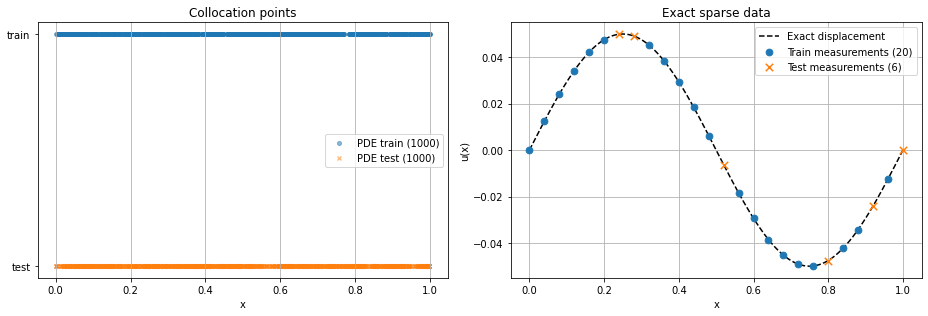

In [117]:
plot_points_and_data()

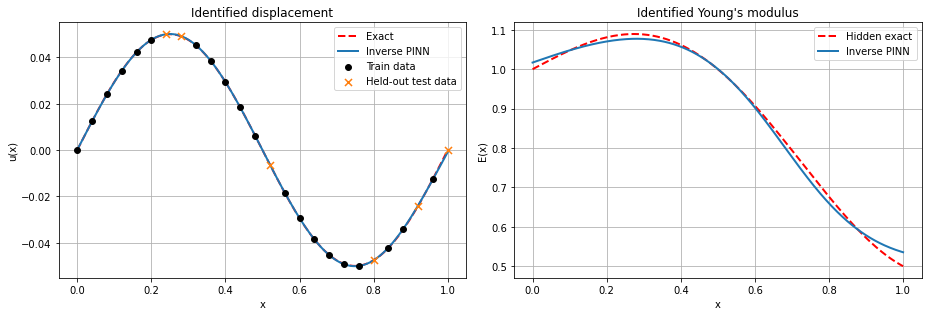

In [118]:
plot_identified_fields()

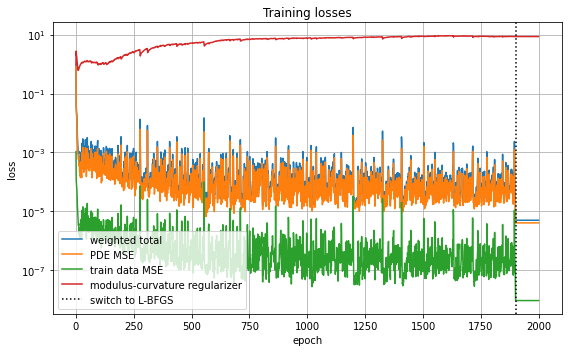

In [119]:
plot_losses()

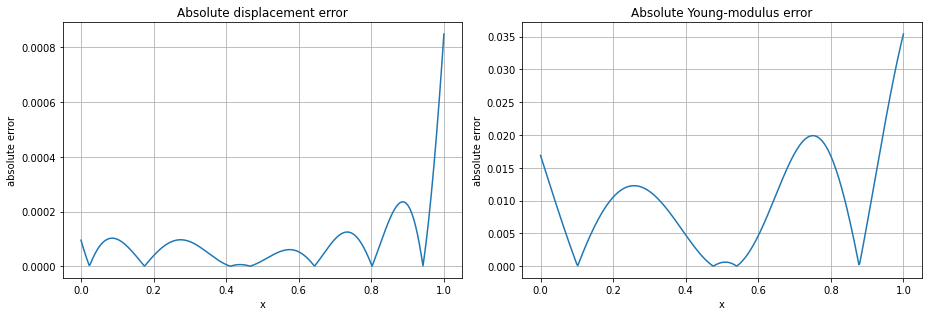

In [120]:
plot_absolute_errors()

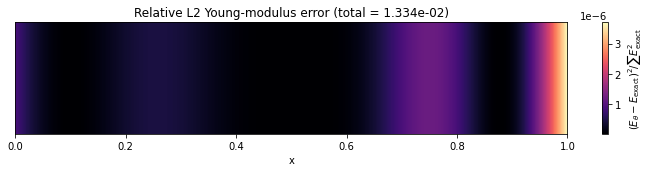

In [121]:
plot_modulus_l2_error_heatmap()